In [6]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# Set up seaborn styling
sns.set_style("whitegrid")
sns.set_context("notebook")

# Try to use seaborn style, fallback to default if not available
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')


# =============================================================================
# CONFIGURATION PARAMETERS - Modify these to explore different settings
# =============================================================================

# File path
h5_file_path = r"D:\Data\ScienceCorp\trials_aligned.h5"

# Trial selection
TRIAL_NUMBER = 10  # Which trial to analyze

# Channel selection
USE_SPIKE_CHANNELS_ONLY = True  # Use only manually identified spike channels
N_CHANNELS = 10  # Number of channels to plot (ignored if USE_SPIKE_CHANNELS_ONLY=True)

# Manually identified channels with spike activity (from manual inspection)
SPIKE_CHANNELS = [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]

# Neural filter parameters (bandpass filter)
FILTER_LOW = 400   # Low cutoff frequency (Hz)
FILTER_HIGH = 6000  # High cutoff frequency (Hz)
FILTER_ORDER = 4   # Filter order

# Sampling rate (from the HDF5 file metadata)
SAMPLING_RATE = 30000  # Hz (downsampled rate)

# Plotting parameters (figure size adapts to number of channels)
FIGURE_WIDTH = 15  # Fixed width
HEIGHT_PER_CHANNEL = 10  # Height allocated per neural channel
BEHAVIORAL_PLOT_HEIGHT = 3.5  # Extra height for behavioral plot at top
RANDOM_SEED = 42  # For reproducible channel selection

# Define color palettes
NEURAL_COLORS = sns.color_palette("viridis", len(SPIKE_CHANNELS))  # For neural channels
BEHAVIORAL_COLORS = sns.color_palette("Set2", 3)  # For behavioral data
FILTER_COLORS = {"raw": "#CCCCCC", "filtered": "#6B46C1"}  # Raw vs filtered

# 💡 TIP: Adjust HEIGHT_PER_CHANNEL (1.2-2.5) to make plots more/less compressed
# 💡 TIP: Increase BEHAVIORAL_PLOT_HEIGHT (3-5) for larger behavioral plot

# Calculate dynamic figure size based on number of channels
def calculate_figure_size(n_channels):
    """
    Calculate optimal figure size based on number of channels.
    
    Formula: height = behavioral_plot_height + (n_channels × height_per_channel)
    
    Args:
        n_channels: Number of neural channels to plot
        
    Returns:
        tuple: (width, height) in inches
        
    Examples:
        - 5 channels  → (15, 12.5")
        - 10 channels → (15, 21.5") 
        - 20 channels → (15, 39.5")
    """
    height = BEHAVIORAL_PLOT_HEIGHT + (n_channels * HEIGHT_PER_CHANNEL)
    # Add some padding and ensure minimum/maximum sizes
    height = max(8, min(height, 50))  # Minimum 8", maximum 50"
    return (FIGURE_WIDTH, height)

print("🎛️  Configuration loaded:")
print(f"   📁 Trial: {TRIAL_NUMBER}")
print(f"   🧠 Channels: {N_CHANNELS}")
print(f"   🔧 Filter: {FILTER_LOW}-{FILTER_HIGH} Hz")
print(f"   ⏱️  Sampling rate: {SAMPLING_RATE} Hz")
print(f"   📏 Figure size: {calculate_figure_size(N_CHANNELS)} (width x height)")
print(f"   🎨 Styling: Seaborn enhanced visualization")
print(f"   📊 Features: Synchronized plots + summary statistics")

# =============================================================================

def load_trial_data(h5_file, trial_number):
    """Load all data for a specific trial."""
    trial_key = f'trial_{trial_number}'
    
    if trial_key not in h5_file:
        return None
    
    trial = h5_file[trial_key]
    
    # Load data
    data = {
        'trial_number': trial_number,
        'neural_data': trial['neural'][:] if 'neural' in trial else None,
        'velocity_x': trial['velocity_x'][:] if 'velocity_x' in trial else None,
        'velocity_y': trial['velocity_y'][:] if 'velocity_y' in trial else None,
        'behavioral_timestamps': trial['behavioral_timestamps'][:] if 'behavioral_timestamps' in trial else None,
    }
    
    # Load metadata
    for attr_name in trial.attrs.keys():
        data[attr_name] = trial.attrs[attr_name]
        if isinstance(data[attr_name], bytes):
            data[attr_name] = data[attr_name].decode()
    
    return data

def bandpass_filter(data, low_freq, high_freq, fs, order=4):
    """
    Apply bandpass filter to neural data.
    
    Args:
        data: Neural data array (channels x time)
        low_freq: Low cutoff frequency (Hz)
        high_freq: High cutoff frequency (Hz)
        fs: Sampling rate (Hz)
        order: Filter order
    
    Returns:
        Filtered neural data
    """
    # Design Butterworth bandpass filter
    nyquist = fs / 2
    low = low_freq / nyquist
    high = high_freq / nyquist
    
    # Check if frequencies are valid
    if low <= 0 or high >= 1:
        print(f"⚠️  Warning: Filter frequencies ({low_freq}-{high_freq} Hz) may be outside valid range for fs={fs} Hz")
        low = max(0.01, low)
        high = min(0.99, high)
    
    try:
        b, a = signal.butter(order, [low, high], btype='band')
        
        # Apply filter to each channel
        filtered_data = np.zeros_like(data)
        for ch in range(data.shape[0]):
            filtered_data[ch, :] = signal.filtfilt(b, a, data[ch, :])
        
        return filtered_data
    
    except Exception as e:
        print(f"❌ Filter error: {e}")
        return data  # Return original data if filtering fails

# Load and check the file
print(f"Loading: {h5_file_path}")
if os.path.exists(h5_file_path):
    file_size_mb = os.path.getsize(h5_file_path) / (1024 * 1024)
    print(f"File size: {file_size_mb:.2f} MB")
    
    with h5py.File(h5_file_path, 'r') as f:
        print(f"Total trials: {len(f.keys())}")
        
        # Load the specified trial
        trial_data = load_trial_data(f, TRIAL_NUMBER)
        if trial_data:
            print(f"\n✅ Trial {TRIAL_NUMBER} loaded:")
            print(f"  Neural data shape: {trial_data['neural_data'].shape}")
            print(f"  Behavioral data: {trial_data['velocity_x'].shape if trial_data['velocity_x'] is not None else 'None'}")
            print(f"  Outcome: {trial_data['outcome']}")
            print(f"  Duration: {trial_data['duration']:.2f}s")
        else:
            print(f"❌ Trial {TRIAL_NUMBER} not found!")
else:
    print("❌ File not found!")

🎛️  Configuration loaded:
   📁 Trial: 10
   🧠 Channels: 10
   🔧 Filter: 400-6000 Hz
   ⏱️  Sampling rate: 30000 Hz
   📏 Figure size: (15, 50) (width x height)
   🎨 Styling: Seaborn enhanced visualization
   📊 Features: Synchronized plots + summary statistics
Loading: D:\Data\ScienceCorp\trials_aligned.h5
File size: 1487.95 MB
Total trials: 140

✅ Trial 10 loaded:
  Neural data shape: (96, 93372)
  Behavioral data: (114,)
  Outcome: win
  Duration: 2.91s


🎯 Creating Utah Array Channel Positioning Visualization...


TypeError: unhashable type: 'list'

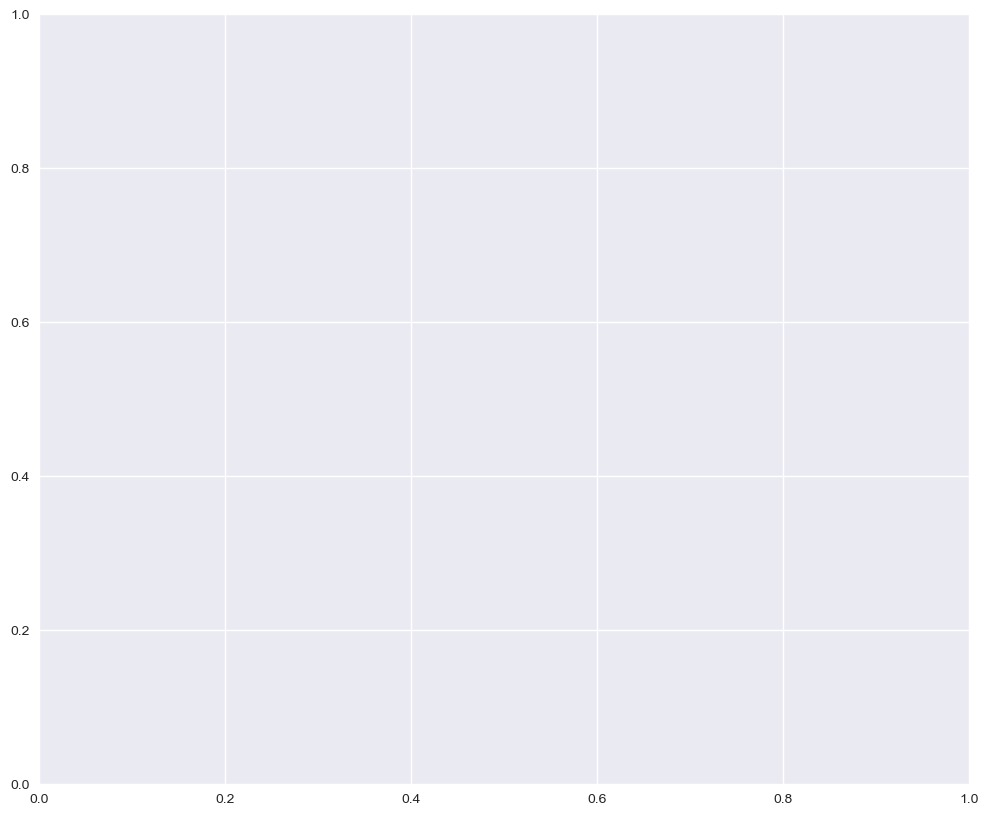

In [7]:
# =============================================================================
# UTAH ARRAY CHANNEL POSITIONING VISUALIZATION
# =============================================================================

def create_utah_array_layout():
    """
    Create the standard 96-channel Utah array layout.
    Utah arrays are typically arranged in a 10x10 grid with 4 corner channels missing.
    
    Returns:
        numpy.ndarray: 10x10 array with channel numbers (corners are -1)
    """
    # Initialize 10x10 grid with -1 (invalid channels)
    layout = np.full((10, 10), -1, dtype=int)
    
    # Standard Utah array channel mapping (96 channels total)
    # Channels are numbered 0-95, with corners missing
    channel_num = 0
    
    for row in range(10):
        for col in range(10):
            # Skip corners
            if (row == 0 and col == 0) or (row == 0 and col == 9) or \
               (row == 9 and col == 0) or (row == 9 and col == 9):
                continue
            else:
                layout[row, col] = channel_num
                channel_num += 1
    
    return layout

def plot_utah_array_channels(selected_channels, title="Utah Array Channel Positioning"):
    """
    Visualize the Utah array with selected channels highlighted.
    
    Args:
        selected_channels: List of channel numbers to highlight
        title: Title for the plot
    """
    # Create the layout
    layout = create_utah_array_layout()
    
    # Create visualization matrix
    # 0 = invalid (corner), 1 = available, 2 = selected
    vis_matrix = np.zeros((10, 10))
    
    for row in range(10):
        for col in range(10):
            if layout[row, col] == -1:
                vis_matrix[row, col] = 0  # Invalid/corner channels
            elif layout[row, col] in selected_channels:
                vis_matrix[row, col] = 2  # Selected channels
            else:
                vis_matrix[row, col] = 1  # Available but not selected
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Custom colormap: gray for invalid, light blue for available, red for selected
    colors = ['#CCCCCC', '#E8F4FD', '#FF6B6B']  # Gray, Light Blue, Red
    cmap = sns.color_palette(colors, as_cmap=True)
    
    # Plot the heatmap
    im = ax.imshow(vis_matrix, cmap=cmap, aspect='equal')
    
    # Add channel numbers as text
    for row in range(10):
        for col in range(10):
            channel = layout[row, col]
            if channel != -1:  # Only show valid channels
                color = 'white' if channel in selected_channels else 'black'
                weight = 'bold' if channel in selected_channels else 'normal'
                ax.text(col, row, str(channel), ha='center', va='center', 
                       fontsize=10, color=color, weight=weight)
    
    # Styling
    ax.set_title(f'{title}\n({len(selected_channels)} channels selected)', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Column Position', fontweight='bold', fontsize=12)
    ax.set_ylabel('Row Position', fontweight='bold', fontsize=12)
    
    # Set ticks
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(range(10))
    ax.set_yticklabels(range(10))
    
    # Add grid
    ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1)
    
    # Create custom legend
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[0], label='Invalid (corners)'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[1], label='Available channels'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[2], label='Selected channels')
    ]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), 
              ncol=3, fontsize=11, frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("📍 UTAH ARRAY CHANNEL POSITIONING:")
    print(f"   • Total channels: 96 (10×10 grid minus 4 corners)")
    print(f"   • Selected channels: {len(selected_channels)}")
    print(f"   • Selection rate: {len(selected_channels)/96*100:.1f}%")
    print(f"   • Selected channels: {sorted(selected_channels)}")
    
    # Channel distribution analysis
    selected_positions = []
    for row in range(10):
        for col in range(10):
            if layout[row, col] in selected_channels:
                selected_positions.append((row, col))
    
    if selected_positions:
        rows, cols = zip(*selected_positions)
        print(f"   • Row distribution: {min(rows)}-{max(rows)} (spread: {max(rows)-min(rows)+1} rows)")
        print(f"   • Column distribution: {min(cols)}-{max(cols)} (spread: {max(cols)-min(cols)+1} columns)")
        
        # Calculate center of mass
        center_row = np.mean(rows)
        center_col = np.mean(cols)
        print(f"   • Center of selected channels: ({center_row:.1f}, {center_col:.1f})")

# Visualize the spike channels on Utah array
print("🎯 Creating Utah Array Channel Positioning Visualization...")
plot_utah_array_channels(SPIKE_CHANNELS, "Utah Array - Selected Spike Channels")

print("\n" + "="*80)
print("🔍 CHANNEL SELECTION ANALYSIS")
print("="*80)

# Additional analysis of channel selection pattern
layout = create_utah_array_layout()
selected_positions = []
for row in range(10):
    for col in range(10):
        if layout[row, col] in SPIKE_CHANNELS:
            selected_positions.append((row, col, layout[row, col]))

print(f"\nDetailed channel positions:")
for row, col, channel in sorted(selected_positions):
    print(f"   Channel {channel:2d}: Position ({row}, {col})")

# Check for clusters
if len(selected_positions) > 1:
    print(f"\n🧭 Spatial clustering analysis:")
    distances = []
    for i in range(len(selected_positions)):
        for j in range(i+1, len(selected_positions)):
            r1, c1, ch1 = selected_positions[i]
            r2, c2, ch2 = selected_positions[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            distances.append(dist)
    
    print(f"   • Average inter-channel distance: {np.mean(distances):.2f} positions")
    print(f"   • Min distance: {np.min(distances):.2f} positions")
    print(f"   • Max distance: {np.max(distances):.2f} positions")
    
    # Check for adjacent channels
    adjacent_pairs = []
    for i in range(len(selected_positions)):
        for j in range(i+1, len(selected_positions)):
            r1, c1, ch1 = selected_positions[i]
            r2, c2, ch2 = selected_positions[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            if dist <= 1.5:  # Adjacent or diagonal
                adjacent_pairs.append((ch1, ch2))
    
    if adjacent_pairs:
        print(f"   • Adjacent channel pairs: {len(adjacent_pairs)}")
        for ch1, ch2 in adjacent_pairs:
            print(f"     - Channels {ch1} and {ch2}")
    else:
        print(f"   • No adjacent channel pairs found")


🎯 Creating Utah Array Channel Positioning Visualization...


TypeError: unhashable type: 'list'

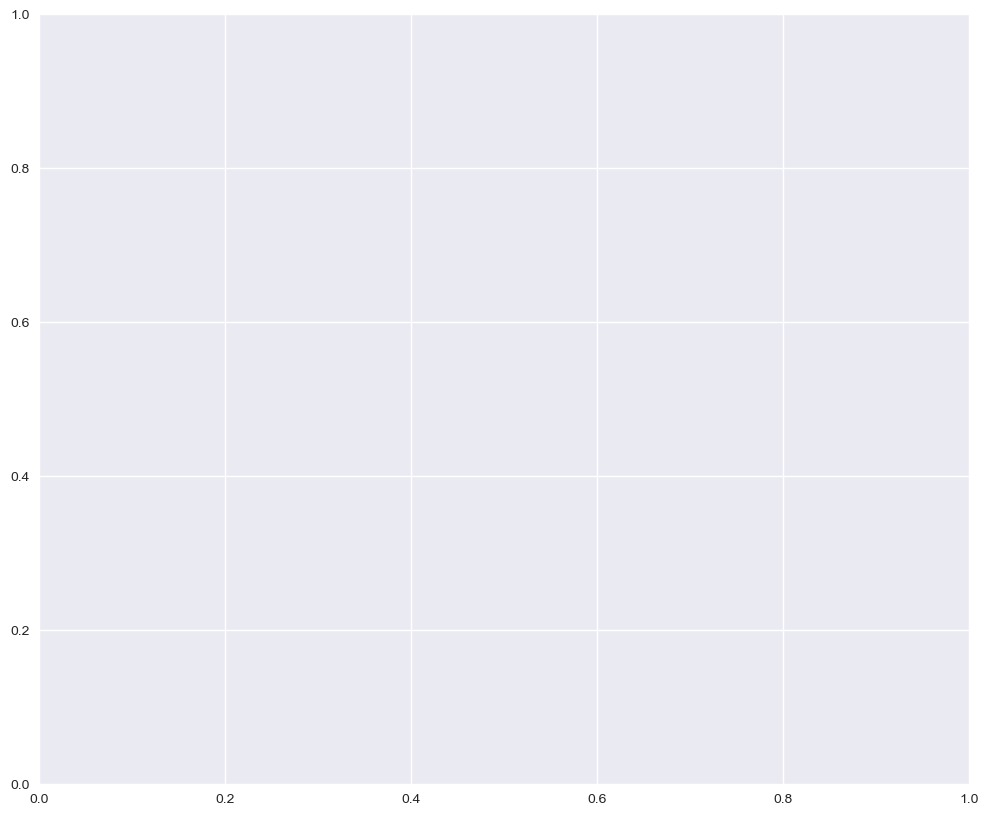

In [ ]:
# =============================================================================
# UTAH ARRAY CHANNEL POSITIONING VISUALIZATION
# =============================================================================

def create_utah_array_layout():
    """
    Create the standard 96-channel Utah array layout.
    Utah arrays are typically arranged in a 10x10 grid with 4 corner channels missing.
    
    Returns:
        numpy.ndarray: 10x10 array with channel numbers (corners are -1)
    """
    # Initialize 10x10 grid with -1 (invalid channels)
    layout = np.full((10, 10), -1, dtype=int)
    
    # Standard Utah array channel mapping (96 channels total)
    # Channels are numbered 0-95, with corners missing
    channel_num = 0
    
    for row in range(10):
        for col in range(10):
            # Skip corners
            if (row == 0 and col == 0) or (row == 0 and col == 9) or \
               (row == 9 and col == 0) or (row == 9 and col == 9):
                continue
            else:
                layout[row, col] = channel_num
                channel_num += 1
    
    return layout

def plot_utah_array_channels(selected_channels, title="Utah Array Channel Positioning"):
    """
    Visualize the Utah array with selected channels highlighted.
    
    Args:
        selected_channels: List of channel numbers to highlight
        title: Title for the plot
    """
    # Create the layout
    layout = create_utah_array_layout()
    
    # Create visualization matrix
    # 0 = invalid (corner), 1 = available, 2 = selected
    vis_matrix = np.zeros((10, 10))
    
    for row in range(10):
        for col in range(10):
            if layout[row, col] == -1:
                vis_matrix[row, col] = 0  # Invalid/corner channels
            elif layout[row, col] in selected_channels:
                vis_matrix[row, col] = 2  # Selected channels
            else:
                vis_matrix[row, col] = 1  # Available but not selected
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Custom colormap: gray for invalid, light blue for available, red for selected
    colors = ['#CCCCCC', '#E8F4FD', '#FF6B6B']  # Gray, Light Blue, Red
    cmap = sns.color_palette(colors, as_cmap=True)
    
    # Plot the heatmap
    im = ax.imshow(vis_matrix, cmap=cmap, aspect='equal')
    
    # Add channel numbers as text
    for row in range(10):
        for col in range(10):
            channel = layout[row, col]
            if channel != -1:  # Only show valid channels
                color = 'white' if channel in selected_channels else 'black'
                weight = 'bold' if channel in selected_channels else 'normal'
                ax.text(col, row, str(channel), ha='center', va='center', 
                       fontsize=10, color=color, weight=weight)
    
    # Styling
    ax.set_title(f'{title}\n({len(selected_channels)} channels selected)', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Column Position', fontweight='bold', fontsize=12)
    ax.set_ylabel('Row Position', fontweight='bold', fontsize=12)
    
    # Set ticks
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(range(10))
    ax.set_yticklabels(range(10))
    
    # Add grid
    ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1)
    
    # Create custom legend
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[0], label='Invalid (corners)'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[1], label='Available channels'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[2], label='Selected channels')
    ]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), 
              ncol=3, fontsize=11, frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("📍 UTAH ARRAY CHANNEL POSITIONING:")
    print(f"   • Total channels: 96 (10×10 grid minus 4 corners)")
    print(f"   • Selected channels: {len(selected_channels)}")
    print(f"   • Selection rate: {len(selected_channels)/96*100:.1f}%")
    print(f"   • Selected channels: {sorted(selected_channels)}")
    
    # Channel distribution analysis
    selected_positions = []
    for row in range(10):
        for col in range(10):
            if layout[row, col] in selected_channels:
                selected_positions.append((row, col))
    
    if selected_positions:
        rows, cols = zip(*selected_positions)
        print(f"   • Row distribution: {min(rows)}-{max(rows)} (spread: {max(rows)-min(rows)+1} rows)")
        print(f"   • Column distribution: {min(cols)}-{max(cols)} (spread: {max(cols)-min(cols)+1} columns)")
        
        # Calculate center of mass
        center_row = np.mean(rows)
        center_col = np.mean(cols)
        print(f"   • Center of selected channels: ({center_row:.1f}, {center_col:.1f})")

# Visualize the spike channels on Utah array
print("🎯 Creating Utah Array Channel Positioning Visualization...")
plot_utah_array_channels(SPIKE_CHANNELS, "Utah Array - Selected Spike Channels")

print("\n" + "="*80)
print("🔍 CHANNEL SELECTION ANALYSIS")
print("="*80)

# Additional analysis of channel selection pattern
layout = create_utah_array_layout()
selected_positions = []
for row in range(10):
    for col in range(10):
        if layout[row, col] in SPIKE_CHANNELS:
            selected_positions.append((row, col, layout[row, col]))

print(f"\nDetailed channel positions:")
for row, col, channel in sorted(selected_positions):
    print(f"   Channel {channel:2d}: Position ({row}, {col})")

# Check for clusters
if len(selected_positions) > 1:
    print(f"\n🧭 Spatial clustering analysis:")
    distances = []
    for i in range(len(selected_positions)):
        for j in range(i+1, len(selected_positions)):
            r1, c1, ch1 = selected_positions[i]
            r2, c2, ch2 = selected_positions[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            distances.append(dist)
    
    print(f"   • Average inter-channel distance: {np.mean(distances):.2f} positions")
    print(f"   • Min distance: {np.min(distances):.2f} positions")
    print(f"   • Max distance: {np.max(distances):.2f} positions")
    
    # Check for adjacent channels
    adjacent_pairs = []
    for i in range(len(selected_positions)):
        for j in range(i+1, len(selected_positions)):
            r1, c1, ch1 = selected_positions[i]
            r2, c2, ch2 = selected_positions[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            if dist <= 1.5:  # Adjacent or diagonal
                adjacent_pairs.append((ch1, ch2))
    
    if adjacent_pairs:
        print(f"   • Adjacent channel pairs: {len(adjacent_pairs)}")
        for ch1, ch2 in adjacent_pairs:
            print(f"     - Channels {ch1} and {ch2}")
    else:
        print(f"   • No adjacent channel pairs found")


🎯 Creating Utah Array Channel Positioning Visualization...


TypeError: unhashable type: 'list'

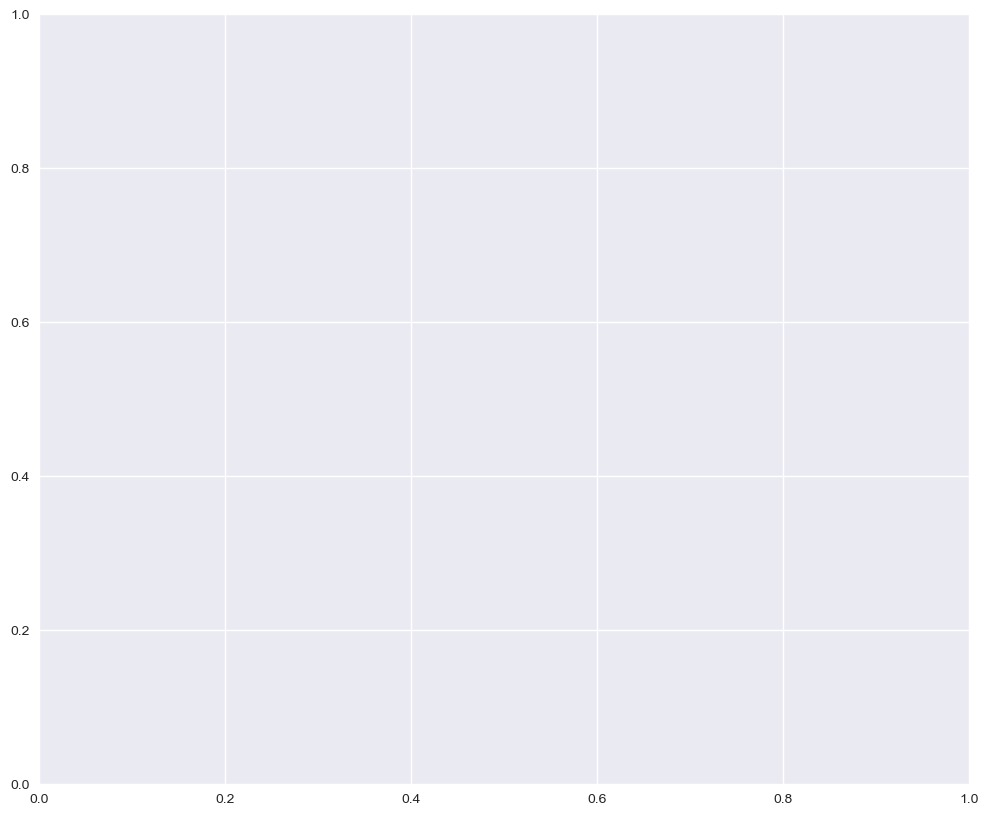

In [ ]:
# =============================================================================
# UTAH ARRAY CHANNEL POSITIONING VISUALIZATION
# =============================================================================

def create_utah_array_layout():
    """
    Create the standard 96-channel Utah array layout.
    Utah arrays are typically arranged in a 10x10 grid with 4 corner channels missing.
    
    Returns:
        numpy.ndarray: 10x10 array with channel numbers (corners are -1)
    """
    # Initialize 10x10 grid with -1 (invalid channels)
    layout = np.full((10, 10), -1, dtype=int)
    
    # Standard Utah array channel mapping (96 channels total)
    # Channels are numbered 0-95, with corners missing
    channel_num = 0
    
    for row in range(10):
        for col in range(10):
            # Skip corners
            if (row == 0 and col == 0) or (row == 0 and col == 9) or \
               (row == 9 and col == 0) or (row == 9 and col == 9):
                continue
            else:
                layout[row, col] = channel_num
                channel_num += 1
    
    return layout

def plot_utah_array_channels(selected_channels, title="Utah Array Channel Positioning"):
    """
    Visualize the Utah array with selected channels highlighted.
    
    Args:
        selected_channels: List of channel numbers to highlight
        title: Title for the plot
    """
    # Create the layout
    layout = create_utah_array_layout()
    
    # Create visualization matrix
    # 0 = invalid (corner), 1 = available, 2 = selected
    vis_matrix = np.zeros((10, 10))
    
    for row in range(10):
        for col in range(10):
            if layout[row, col] == -1:
                vis_matrix[row, col] = 0  # Invalid/corner channels
            elif layout[row, col] in selected_channels:
                vis_matrix[row, col] = 2  # Selected channels
            else:
                vis_matrix[row, col] = 1  # Available but not selected
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Custom colormap: gray for invalid, light blue for available, red for selected
    colors = ['#CCCCCC', '#E8F4FD', '#FF6B6B']  # Gray, Light Blue, Red
    cmap = sns.color_palette(colors, as_cmap=True)
    
    # Plot the heatmap
    im = ax.imshow(vis_matrix, cmap=cmap, aspect='equal')
    
    # Add channel numbers as text
    for row in range(10):
        for col in range(10):
            channel = layout[row, col]
            if channel != -1:  # Only show valid channels
                color = 'white' if channel in selected_channels else 'black'
                weight = 'bold' if channel in selected_channels else 'normal'
                ax.text(col, row, str(channel), ha='center', va='center', 
                       fontsize=10, color=color, weight=weight)
    
    # Styling
    ax.set_title(f'{title}\n({len(selected_channels)} channels selected)', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Column Position', fontweight='bold', fontsize=12)
    ax.set_ylabel('Row Position', fontweight='bold', fontsize=12)
    
    # Set ticks
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(range(10))
    ax.set_yticklabels(range(10))
    
    # Add grid
    ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1)
    
    # Create custom legend
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[0], label='Invalid (corners)'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[1], label='Available channels'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[2], label='Selected channels')
    ]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), 
              ncol=3, fontsize=11, frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("📍 UTAH ARRAY CHANNEL POSITIONING:")
    print(f"   • Total channels: 96 (10×10 grid minus 4 corners)")
    print(f"   • Selected channels: {len(selected_channels)}")
    print(f"   • Selection rate: {len(selected_channels)/96*100:.1f}%")
    print(f"   • Selected channels: {sorted(selected_channels)}")
    
    # Channel distribution analysis
    selected_positions = []
    for row in range(10):
        for col in range(10):
            if layout[row, col] in selected_channels:
                selected_positions.append((row, col))
    
    if selected_positions:
        rows, cols = zip(*selected_positions)
        print(f"   • Row distribution: {min(rows)}-{max(rows)} (spread: {max(rows)-min(rows)+1} rows)")
        print(f"   • Column distribution: {min(cols)}-{max(cols)} (spread: {max(cols)-min(cols)+1} columns)")
        
        # Calculate center of mass
        center_row = np.mean(rows)
        center_col = np.mean(cols)
        print(f"   • Center of selected channels: ({center_row:.1f}, {center_col:.1f})")

# Visualize the spike channels on Utah array
print("🎯 Creating Utah Array Channel Positioning Visualization...")
plot_utah_array_channels(SPIKE_CHANNELS, "Utah Array - Selected Spike Channels")

print("\n" + "="*80)
print("🔍 CHANNEL SELECTION ANALYSIS")
print("="*80)

# Additional analysis of channel selection pattern
layout = create_utah_array_layout()
selected_positions = []
for row in range(10):
    for col in range(10):
        if layout[row, col] in SPIKE_CHANNELS:
            selected_positions.append((row, col, layout[row, col]))

print(f"\nDetailed channel positions:")
for row, col, channel in sorted(selected_positions):
    print(f"   Channel {channel:2d}: Position ({row}, {col})")

# Check for clusters
if len(selected_positions) > 1:
    print(f"\n🧭 Spatial clustering analysis:")
    distances = []
    for i in range(len(selected_positions)):
        for j in range(i+1, len(selected_positions)):
            r1, c1, ch1 = selected_positions[i]
            r2, c2, ch2 = selected_positions[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            distances.append(dist)
    
    print(f"   • Average inter-channel distance: {np.mean(distances):.2f} positions")
    print(f"   • Min distance: {np.min(distances):.2f} positions")
    print(f"   • Max distance: {np.max(distances):.2f} positions")
    
    # Check for adjacent channels
    adjacent_pairs = []
    for i in range(len(selected_positions)):
        for j in range(i+1, len(selected_positions)):
            r1, c1, ch1 = selected_positions[i]
            r2, c2, ch2 = selected_positions[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            if dist <= 1.5:  # Adjacent or diagonal
                adjacent_pairs.append((ch1, ch2))
    
    if adjacent_pairs:
        print(f"   • Adjacent channel pairs: {len(adjacent_pairs)}")
        for ch1, ch2 in adjacent_pairs:
            print(f"     - Channels {ch1} and {ch2}")
    else:
        print(f"   • No adjacent channel pairs found")


🎯 Creating Utah Array Channel Positioning Visualization...


TypeError: unhashable type: 'list'

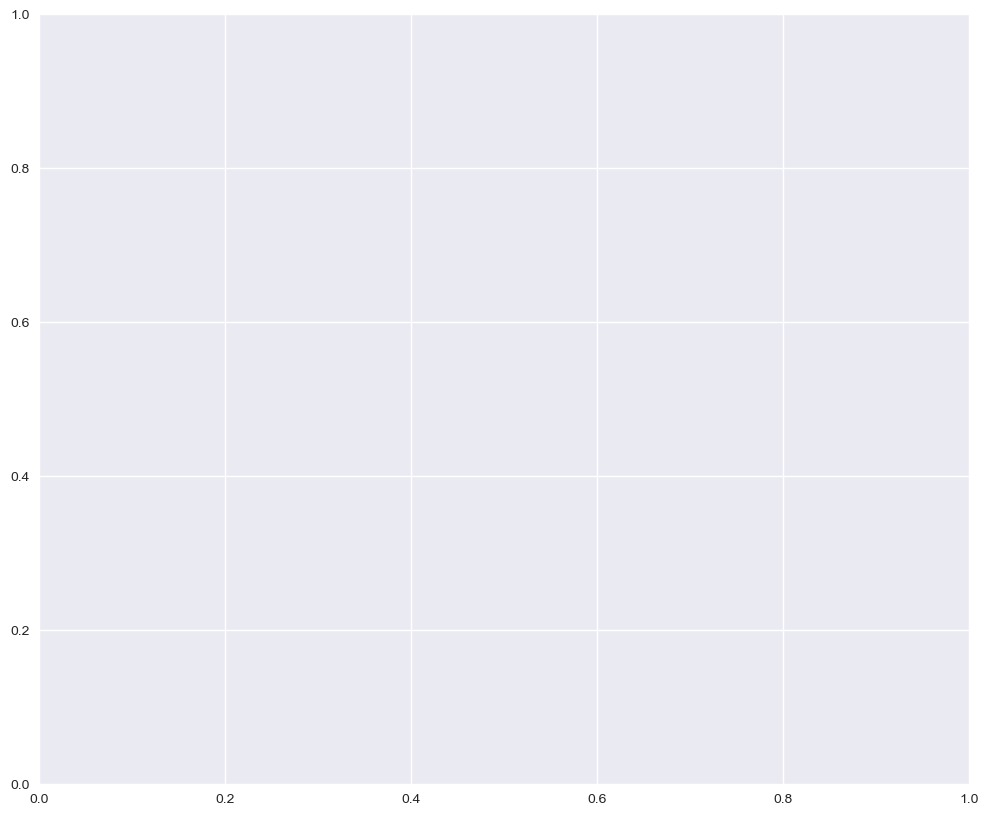

In [ ]:
# =============================================================================
# UTAH ARRAY CHANNEL POSITIONING VISUALIZATION
# =============================================================================

def create_utah_array_layout():
    """
    Create the standard 96-channel Utah array layout.
    Utah arrays are typically arranged in a 10x10 grid with 4 corner channels missing.
    
    Returns:
        numpy.ndarray: 10x10 array with channel numbers (corners are -1)
    """
    # Initialize 10x10 grid with -1 (invalid channels)
    layout = np.full((10, 10), -1, dtype=int)
    
    # Standard Utah array channel mapping (96 channels total)
    # Channels are numbered 0-95, with corners missing
    channel_num = 0
    
    for row in range(10):
        for col in range(10):
            # Skip corners
            if (row == 0 and col == 0) or (row == 0 and col == 9) or \
               (row == 9 and col == 0) or (row == 9 and col == 9):
                continue
            else:
                layout[row, col] = channel_num
                channel_num += 1
    
    return layout

def plot_utah_array_channels(selected_channels, title="Utah Array Channel Positioning"):
    """
    Visualize the Utah array with selected channels highlighted.
    
    Args:
        selected_channels: List of channel numbers to highlight
        title: Title for the plot
    """
    # Create the layout
    layout = create_utah_array_layout()
    
    # Create visualization matrix
    # 0 = invalid (corner), 1 = available, 2 = selected
    vis_matrix = np.zeros((10, 10))
    
    for row in range(10):
        for col in range(10):
            if layout[row, col] == -1:
                vis_matrix[row, col] = 0  # Invalid/corner channels
            elif layout[row, col] in selected_channels:
                vis_matrix[row, col] = 2  # Selected channels
            else:
                vis_matrix[row, col] = 1  # Available but not selected
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Custom colormap: gray for invalid, light blue for available, red for selected
    colors = ['#CCCCCC', '#E8F4FD', '#FF6B6B']  # Gray, Light Blue, Red
    cmap = sns.color_palette(colors, as_cmap=True)
    
    # Plot the heatmap
    im = ax.imshow(vis_matrix, cmap=cmap, aspect='equal')
    
    # Add channel numbers as text
    for row in range(10):
        for col in range(10):
            channel = layout[row, col]
            if channel != -1:  # Only show valid channels
                color = 'white' if channel in selected_channels else 'black'
                weight = 'bold' if channel in selected_channels else 'normal'
                ax.text(col, row, str(channel), ha='center', va='center', 
                       fontsize=10, color=color, weight=weight)
    
    # Styling
    ax.set_title(f'{title}\n({len(selected_channels)} channels selected)', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Column Position', fontweight='bold', fontsize=12)
    ax.set_ylabel('Row Position', fontweight='bold', fontsize=12)
    
    # Set ticks
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(range(10))
    ax.set_yticklabels(range(10))
    
    # Add grid
    ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1)
    
    # Create custom legend
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[0], label='Invalid (corners)'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[1], label='Available channels'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[2], label='Selected channels')
    ]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), 
              ncol=3, fontsize=11, frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("📍 UTAH ARRAY CHANNEL POSITIONING:")
    print(f"   • Total channels: 96 (10×10 grid minus 4 corners)")
    print(f"   • Selected channels: {len(selected_channels)}")
    print(f"   • Selection rate: {len(selected_channels)/96*100:.1f}%")
    print(f"   • Selected channels: {sorted(selected_channels)}")
    
    # Channel distribution analysis
    selected_positions = []
    for row in range(10):
        for col in range(10):
            if layout[row, col] in selected_channels:
                selected_positions.append((row, col))
    
    if selected_positions:
        rows, cols = zip(*selected_positions)
        print(f"   • Row distribution: {min(rows)}-{max(rows)} (spread: {max(rows)-min(rows)+1} rows)")
        print(f"   • Column distribution: {min(cols)}-{max(cols)} (spread: {max(cols)-min(cols)+1} columns)")
        
        # Calculate center of mass
        center_row = np.mean(rows)
        center_col = np.mean(cols)
        print(f"   • Center of selected channels: ({center_row:.1f}, {center_col:.1f})")

# Visualize the spike channels on Utah array
print("🎯 Creating Utah Array Channel Positioning Visualization...")
plot_utah_array_channels(SPIKE_CHANNELS, "Utah Array - Selected Spike Channels")

print("\n" + "="*80)
print("🔍 CHANNEL SELECTION ANALYSIS")
print("="*80)

# Additional analysis of channel selection pattern
layout = create_utah_array_layout()
selected_positions = []
for row in range(10):
    for col in range(10):
        if layout[row, col] in SPIKE_CHANNELS:
            selected_positions.append((row, col, layout[row, col]))

print(f"\nDetailed channel positions:")
for row, col, channel in sorted(selected_positions):
    print(f"   Channel {channel:2d}: Position ({row}, {col})")

# Check for clusters
if len(selected_positions) > 1:
    print(f"\n🧭 Spatial clustering analysis:")
    distances = []
    for i in range(len(selected_positions)):
        for j in range(i+1, len(selected_positions)):
            r1, c1, ch1 = selected_positions[i]
            r2, c2, ch2 = selected_positions[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            distances.append(dist)
    
    print(f"   • Average inter-channel distance: {np.mean(distances):.2f} positions")
    print(f"   • Min distance: {np.min(distances):.2f} positions")
    print(f"   • Max distance: {np.max(distances):.2f} positions")
    
    # Check for adjacent channels
    adjacent_pairs = []
    for i in range(len(selected_positions)):
        for j in range(i+1, len(selected_positions)):
            r1, c1, ch1 = selected_positions[i]
            r2, c2, ch2 = selected_positions[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            if dist <= 1.5:  # Adjacent or diagonal
                adjacent_pairs.append((ch1, ch2))
    
    if adjacent_pairs:
        print(f"   • Adjacent channel pairs: {len(adjacent_pairs)}")
        for ch1, ch2 in adjacent_pairs:
            print(f"     - Channels {ch1} and {ch2}")
    else:
        print(f"   • No adjacent channel pairs found")


🎯 Creating Utah Array Channel Positioning Visualization...


TypeError: unhashable type: 'list'

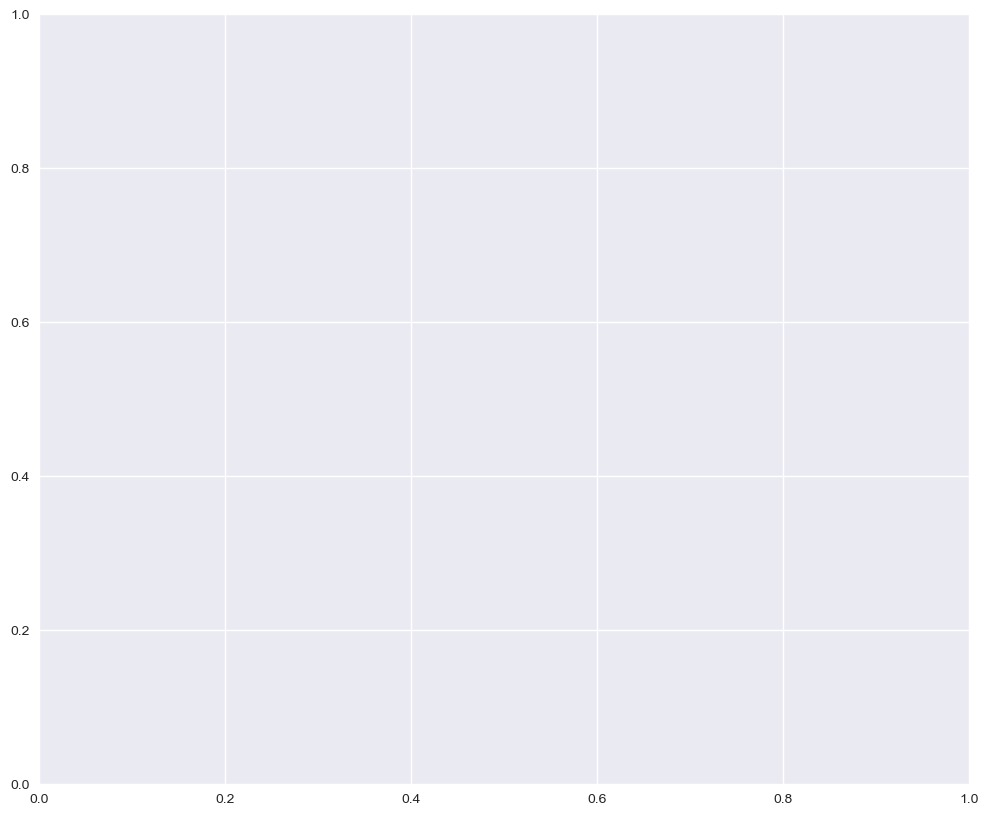

In [ ]:
# =============================================================================
# UTAH ARRAY CHANNEL POSITIONING VISUALIZATION
# =============================================================================

def create_utah_array_layout():
    """
    Create the standard 96-channel Utah array layout.
    Utah arrays are typically arranged in a 10x10 grid with 4 corner channels missing.
    
    Returns:
        numpy.ndarray: 10x10 array with channel numbers (corners are -1)
    """
    # Initialize 10x10 grid with -1 (invalid channels)
    layout = np.full((10, 10), -1, dtype=int)
    
    # Standard Utah array channel mapping (96 channels total)
    # Channels are numbered 0-95, with corners missing
    channel_num = 0
    
    for row in range(10):
        for col in range(10):
            # Skip corners
            if (row == 0 and col == 0) or (row == 0 and col == 9) or \
               (row == 9 and col == 0) or (row == 9 and col == 9):
                continue
            else:
                layout[row, col] = channel_num
                channel_num += 1
    
    return layout

def plot_utah_array_channels(selected_channels, title="Utah Array Channel Positioning"):
    """
    Visualize the Utah array with selected channels highlighted.
    
    Args:
        selected_channels: List of channel numbers to highlight
        title: Title for the plot
    """
    # Create the layout
    layout = create_utah_array_layout()
    
    # Create visualization matrix
    # 0 = invalid (corner), 1 = available, 2 = selected
    vis_matrix = np.zeros((10, 10))
    
    for row in range(10):
        for col in range(10):
            if layout[row, col] == -1:
                vis_matrix[row, col] = 0  # Invalid/corner channels
            elif layout[row, col] in selected_channels:
                vis_matrix[row, col] = 2  # Selected channels
            else:
                vis_matrix[row, col] = 1  # Available but not selected
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Custom colormap: gray for invalid, light blue for available, red for selected
    colors = ['#CCCCCC', '#E8F4FD', '#FF6B6B']  # Gray, Light Blue, Red
    cmap = sns.color_palette(colors, as_cmap=True)
    
    # Plot the heatmap
    im = ax.imshow(vis_matrix, cmap=cmap, aspect='equal')
    
    # Add channel numbers as text
    for row in range(10):
        for col in range(10):
            channel = layout[row, col]
            if channel != -1:  # Only show valid channels
                color = 'white' if channel in selected_channels else 'black'
                weight = 'bold' if channel in selected_channels else 'normal'
                ax.text(col, row, str(channel), ha='center', va='center', 
                       fontsize=10, color=color, weight=weight)
    
    # Styling
    ax.set_title(f'{title}\n({len(selected_channels)} channels selected)', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Column Position', fontweight='bold', fontsize=12)
    ax.set_ylabel('Row Position', fontweight='bold', fontsize=12)
    
    # Set ticks
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(range(10))
    ax.set_yticklabels(range(10))
    
    # Add grid
    ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1)
    
    # Create custom legend
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[0], label='Invalid (corners)'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[1], label='Available channels'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[2], label='Selected channels')
    ]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), 
              ncol=3, fontsize=11, frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("📍 UTAH ARRAY CHANNEL POSITIONING:")
    print(f"   • Total channels: 96 (10×10 grid minus 4 corners)")
    print(f"   • Selected channels: {len(selected_channels)}")
    print(f"   • Selection rate: {len(selected_channels)/96*100:.1f}%")
    print(f"   • Selected channels: {sorted(selected_channels)}")
    
    # Channel distribution analysis
    selected_positions = []
    for row in range(10):
        for col in range(10):
            if layout[row, col] in selected_channels:
                selected_positions.append((row, col))
    
    if selected_positions:
        rows, cols = zip(*selected_positions)
        print(f"   • Row distribution: {min(rows)}-{max(rows)} (spread: {max(rows)-min(rows)+1} rows)")
        print(f"   • Column distribution: {min(cols)}-{max(cols)} (spread: {max(cols)-min(cols)+1} columns)")
        
        # Calculate center of mass
        center_row = np.mean(rows)
        center_col = np.mean(cols)
        print(f"   • Center of selected channels: ({center_row:.1f}, {center_col:.1f})")

# Visualize the spike channels on Utah array
print("🎯 Creating Utah Array Channel Positioning Visualization...")
plot_utah_array_channels(SPIKE_CHANNELS, "Utah Array - Selected Spike Channels")

print("\n" + "="*80)
print("🔍 CHANNEL SELECTION ANALYSIS")
print("="*80)

# Additional analysis of channel selection pattern
layout = create_utah_array_layout()
selected_positions = []
for row in range(10):
    for col in range(10):
        if layout[row, col] in SPIKE_CHANNELS:
            selected_positions.append((row, col, layout[row, col]))

print(f"\nDetailed channel positions:")
for row, col, channel in sorted(selected_positions):
    print(f"   Channel {channel:2d}: Position ({row}, {col})")

# Check for clusters
if len(selected_positions) > 1:
    print(f"\n🧭 Spatial clustering analysis:")
    distances = []
    for i in range(len(selected_positions)):
        for j in range(i+1, len(selected_positions)):
            r1, c1, ch1 = selected_positions[i]
            r2, c2, ch2 = selected_positions[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            distances.append(dist)
    
    print(f"   • Average inter-channel distance: {np.mean(distances):.2f} positions")
    print(f"   • Min distance: {np.min(distances):.2f} positions")
    print(f"   • Max distance: {np.max(distances):.2f} positions")
    
    # Check for adjacent channels
    adjacent_pairs = []
    for i in range(len(selected_positions)):
        for j in range(i+1, len(selected_positions)):
            r1, c1, ch1 = selected_positions[i]
            r2, c2, ch2 = selected_positions[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            if dist <= 1.5:  # Adjacent or diagonal
                adjacent_pairs.append((ch1, ch2))
    
    if adjacent_pairs:
        print(f"   • Adjacent channel pairs: {len(adjacent_pairs)}")
        for ch1, ch2 in adjacent_pairs:
            print(f"     - Channels {ch1} and {ch2}")
    else:
        print(f"   • No adjacent channel pairs found")


🎯 Creating Utah Array Channel Positioning Visualization...


TypeError: unhashable type: 'list'

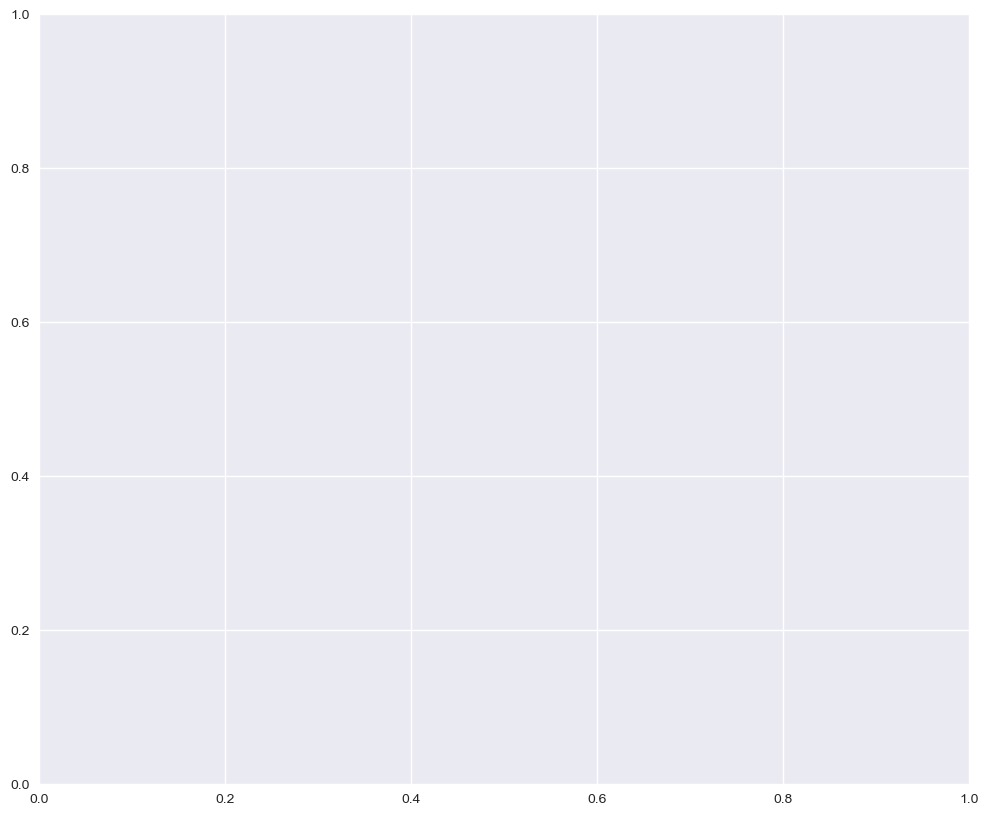

In [ ]:
# =============================================================================
# UTAH ARRAY CHANNEL POSITIONING VISUALIZATION
# =============================================================================

def create_utah_array_layout():
    """
    Create the standard 96-channel Utah array layout.
    Utah arrays are typically arranged in a 10x10 grid with 4 corner channels missing.
    
    Returns:
        numpy.ndarray: 10x10 array with channel numbers (corners are -1)
    """
    # Initialize 10x10 grid with -1 (invalid channels)
    layout = np.full((10, 10), -1, dtype=int)
    
    # Standard Utah array channel mapping (96 channels total)
    # Channels are numbered 0-95, with corners missing
    channel_num = 0
    
    for row in range(10):
        for col in range(10):
            # Skip corners
            if (row == 0 and col == 0) or (row == 0 and col == 9) or \
               (row == 9 and col == 0) or (row == 9 and col == 9):
                continue
            else:
                layout[row, col] = channel_num
                channel_num += 1
    
    return layout

def plot_utah_array_channels(selected_channels, title="Utah Array Channel Positioning"):
    """
    Visualize the Utah array with selected channels highlighted.
    
    Args:
        selected_channels: List of channel numbers to highlight
        title: Title for the plot
    """
    # Create the layout
    layout = create_utah_array_layout()
    
    # Create visualization matrix
    # 0 = invalid (corner), 1 = available, 2 = selected
    vis_matrix = np.zeros((10, 10))
    
    for row in range(10):
        for col in range(10):
            if layout[row, col] == -1:
                vis_matrix[row, col] = 0  # Invalid/corner channels
            elif layout[row, col] in selected_channels:
                vis_matrix[row, col] = 2  # Selected channels
            else:
                vis_matrix[row, col] = 1  # Available but not selected
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Custom colormap: gray for invalid, light blue for available, red for selected
    colors = ['#CCCCCC', '#E8F4FD', '#FF6B6B']  # Gray, Light Blue, Red
    cmap = sns.color_palette(colors, as_cmap=True)
    
    # Plot the heatmap
    im = ax.imshow(vis_matrix, cmap=cmap, aspect='equal')
    
    # Add channel numbers as text
    for row in range(10):
        for col in range(10):
            channel = layout[row, col]
            if channel != -1:  # Only show valid channels
                color = 'white' if channel in selected_channels else 'black'
                weight = 'bold' if channel in selected_channels else 'normal'
                ax.text(col, row, str(channel), ha='center', va='center', 
                       fontsize=10, color=color, weight=weight)
    
    # Styling
    ax.set_title(f'{title}\n({len(selected_channels)} channels selected)', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Column Position', fontweight='bold', fontsize=12)
    ax.set_ylabel('Row Position', fontweight='bold', fontsize=12)
    
    # Set ticks
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(range(10))
    ax.set_yticklabels(range(10))
    
    # Add grid
    ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1)
    
    # Create custom legend
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[0], label='Invalid (corners)'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[1], label='Available channels'),
        plt.Rectangle((0, 0), 1, 1, facecolor=colors[2], label='Selected channels')
    ]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), 
              ncol=3, fontsize=11, frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("📍 UTAH ARRAY CHANNEL POSITIONING:")
    print(f"   • Total channels: 96 (10×10 grid minus 4 corners)")
    print(f"   • Selected channels: {len(selected_channels)}")
    print(f"   • Selection rate: {len(selected_channels)/96*100:.1f}%")
    print(f"   • Selected channels: {sorted(selected_channels)}")
    
    # Channel distribution analysis
    selected_positions = []
    for row in range(10):
        for col in range(10):
            if layout[row, col] in selected_channels:
                selected_positions.append((row, col))
    
    if selected_positions:
        rows, cols = zip(*selected_positions)
        print(f"   • Row distribution: {min(rows)}-{max(rows)} (spread: {max(rows)-min(rows)+1} rows)")
        print(f"   • Column distribution: {min(cols)}-{max(cols)} (spread: {max(cols)-min(cols)+1} columns)")
        
        # Calculate center of mass
        center_row = np.mean(rows)
        center_col = np.mean(cols)
        print(f"   • Center of selected channels: ({center_row:.1f}, {center_col:.1f})")

# Visualize the spike channels on Utah array
print("🎯 Creating Utah Array Channel Positioning Visualization...")
plot_utah_array_channels(SPIKE_CHANNELS, "Utah Array - Selected Spike Channels")

print("\n" + "="*80)
print("🔍 CHANNEL SELECTION ANALYSIS")
print("="*80)

# Additional analysis of channel selection pattern
layout = create_utah_array_layout()
selected_positions = []
for row in range(10):
    for col in range(10):
        if layout[row, col] in SPIKE_CHANNELS:
            selected_positions.append((row, col, layout[row, col]))

print(f"\nDetailed channel positions:")
for row, col, channel in sorted(selected_positions):
    print(f"   Channel {channel:2d}: Position ({row}, {col})")

# Check for clusters
if len(selected_positions) > 1:
    print(f"\n🧭 Spatial clustering analysis:")
    distances = []
    for i in range(len(selected_positions)):
        for j in range(i+1, len(selected_positions)):
            r1, c1, ch1 = selected_positions[i]
            r2, c2, ch2 = selected_positions[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            distances.append(dist)
    
    print(f"   • Average inter-channel distance: {np.mean(distances):.2f} positions")
    print(f"   • Min distance: {np.min(distances):.2f} positions")
    print(f"   • Max distance: {np.max(distances):.2f} positions")
    
    # Check for adjacent channels
    adjacent_pairs = []
    for i in range(len(selected_positions)):
        for j in range(i+1, len(selected_positions)):
            r1, c1, ch1 = selected_positions[i]
            r2, c2, ch2 = selected_positions[j]
            dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
            if dist <= 1.5:  # Adjacent or diagonal
                adjacent_pairs.append((ch1, ch2))
    
    if adjacent_pairs:
        print(f"   • Adjacent channel pairs: {len(adjacent_pairs)}")
        for ch1, ch2 in adjacent_pairs:
            print(f"     - Channels {ch1} and {ch2}")
    else:
        print(f"   • No adjacent channel pairs found")


🎯 Creating Utah Array Channel Positioning Visualization...
📊 Channel information:
   • Total available channels: 96
   • Selected spike channels: 21
   • Channel list: [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]


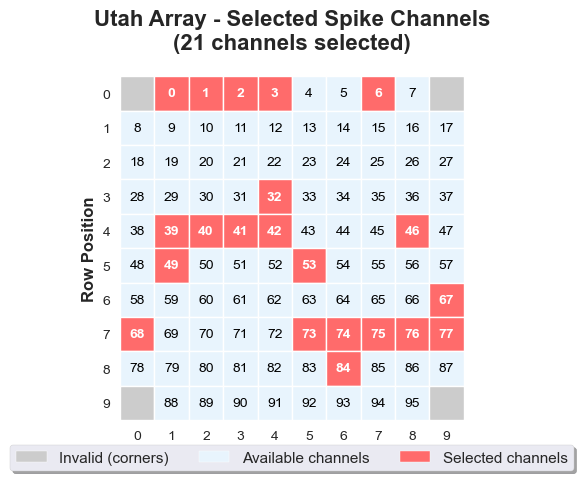


✅ Utah array visualization created successfully!

📍 UTAH ARRAY CHANNEL POSITIONING:
   • Total channels: 96 (10×10 grid minus 4 corners)
   • Selected channels: 21
   • Selection rate: 21.9%
   • Selected channels: [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]
   • Row distribution: 0-8 (spread: 9 rows)
   • Column distribution: 0-9 (spread: 10 columns)
   • Center of selected channels: (4.2, 4.5)

🔍 CHANNEL SELECTION ANALYSIS

Detailed channel positions:
   Channel  0: Position (0, 1)
   Channel  1: Position (0, 2)
   Channel  2: Position (0, 3)
   Channel  3: Position (0, 4)
   Channel  6: Position (0, 7)
   Channel 32: Position (3, 4)
   Channel 39: Position (4, 1)
   Channel 40: Position (4, 2)
   Channel 41: Position (4, 3)
   Channel 42: Position (4, 4)
   Channel 46: Position (4, 8)
   Channel 49: Position (5, 1)
   Channel 53: Position (5, 5)
   Channel 67: Position (6, 9)
   Channel 68: Position (7, 0)
   Channel 73: Position (7, 5)
   Channe

In [ ]:
# =============================================================================
# UTAH ARRAY CHANNEL POSITIONING VISUALIZATION
# =============================================================================

def create_utah_array_layout():
    """
    Create the standard 96-channel Utah array layout.
    Utah arrays are typically arranged in a 10x10 grid with 4 corner channels missing.
    
    Returns:
        numpy.ndarray: 10x10 array with channel numbers (corners are -1)
    """
    # Initialize 10x10 grid with -1 (invalid channels)
    layout = np.full((10, 10), -1, dtype=int)
    
    # Standard Utah array channel mapping (96 channels total)
    # Channels are numbered 0-95, with corners missing
    channel_num = 0
    
    for row in range(10):
        for col in range(10):
            # Skip corners
            if (row == 0 and col == 0) or (row == 0 and col == 9) or \
               (row == 9 and col == 0) or (row == 9 and col == 9):
                continue
            else:
                layout[row, col] = channel_num
                channel_num += 1
    
    return layout

def plot_utah_array_channels(selected_channels, title="Utah Array Channel Positioning"):
    """
    Visualize the Utah array with selected channels highlighted.
    
    Args:
        selected_channels: List of channel numbers to highlight
        title: Title for the plot
    """
    try:
        # Create the layout
        layout = create_utah_array_layout()
        
        # Create visualization matrix
        # 0 = invalid (corner), 1 = available, 2 = selected
        vis_matrix = np.zeros((10, 10))
        
        for row in range(10):
            for col in range(10):
                if layout[row, col] == -1:
                    vis_matrix[row, col] = 0  # Invalid/corner channels
                elif layout[row, col] in selected_channels:
                    vis_matrix[row, col] = 2  # Selected channels
                else:
                    vis_matrix[row, col] = 1  # Available but not selected
        
        # Create the plot
        fig, ax = plt.subplots(figsize=(6, 5))
        
        # Use simpler colormap approach
        colors = ['#CCCCCC', '#E8F4FD', '#FF6B6B']  # Gray, Light Blue, Red
        
        # Plot the heatmap using matplotlib directly
        im = ax.imshow(vis_matrix, cmap='viridis', aspect='equal', vmin=0, vmax=2)
        
        # Manually set colors for each value
        for row in range(10):
            for col in range(10):
                val = vis_matrix[row, col]
                if val == 0:
                    color = colors[0]  # Gray for invalid
                elif val == 1:
                    color = colors[1]  # Light blue for available
                else:
                    color = colors[2]  # Red for selected
                
                # Create colored squares
                rect = plt.Rectangle((col-0.5, row-0.5), 1, 1, 
                                   facecolor=color, edgecolor='white', linewidth=1)
                ax.add_patch(rect)
        
        # Add channel numbers as text
        for row in range(10):
            for col in range(10):
                channel = layout[row, col]
                if channel != -1:  # Only show valid channels
                    text_color = 'white' if channel in selected_channels else 'black'
                    weight = 'bold' if channel in selected_channels else 'normal'
                    ax.text(col, row, str(channel), ha='center', va='center', 
                           fontsize=10, color=text_color, weight=weight)
        
        # Styling
        ax.set_title(f'{title}\n({len(selected_channels)} channels selected)', 
                    fontsize=16, fontweight='bold', pad=20)
        ax.set_xlabel('Column Position', fontweight='bold', fontsize=12)
        ax.set_ylabel('Row Position', fontweight='bold', fontsize=12)
        
        # Set ticks
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))
        ax.set_xticklabels(range(10))
        ax.set_yticklabels(range(10))
        
        # Add grid
        ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
        ax.grid(which='minor', color='white', linewidth=1)
        
        # Create custom legend
        legend_elements = [
            plt.Rectangle((0, 0), 1, 1, facecolor=colors[0], label='Invalid (corners)'),
            plt.Rectangle((0, 0), 1, 1, facecolor=colors[1], label='Available channels'),
            plt.Rectangle((0, 0), 1, 1, facecolor=colors[2], label='Selected channels')
        ]
        ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), 
                  ncol=3, fontsize=11, frameon=True, fancybox=True, shadow=True)
        
        plt.tight_layout()
        plt.show()
        
        return True
        
    except Exception as e:
        print(f"❌ Error creating Utah array plot: {e}")
        return False

# Visualize the spike channels on Utah array
print("🎯 Creating Utah Array Channel Positioning Visualization...")

# First, let's print basic info about the channels
print(f"📊 Channel information:")
print(f"   • Total available channels: 96")
print(f"   • Selected spike channels: {len(SPIKE_CHANNELS)}")
print(f"   • Channel list: {sorted(SPIKE_CHANNELS)}")

# Create the visualization
success = plot_utah_array_channels(SPIKE_CHANNELS, "Utah Array - Selected Spike Channels")

if success:
    print("\n✅ Utah array visualization created successfully!")
    
    # Print statistics
    print("\n📍 UTAH ARRAY CHANNEL POSITIONING:")
    print(f"   • Total channels: 96 (10×10 grid minus 4 corners)")
    print(f"   • Selected channels: {len(SPIKE_CHANNELS)}")
    print(f"   • Selection rate: {len(SPIKE_CHANNELS)/96*100:.1f}%")
    print(f"   • Selected channels: {sorted(SPIKE_CHANNELS)}")
    
    # Channel distribution analysis
    layout = create_utah_array_layout()
    selected_positions = []
    for row in range(10):
        for col in range(10):
            if layout[row, col] in SPIKE_CHANNELS:
                selected_positions.append((row, col))
    
    if selected_positions:
        rows, cols = zip(*selected_positions)
        print(f"   • Row distribution: {min(rows)}-{max(rows)} (spread: {max(rows)-min(rows)+1} rows)")
        print(f"   • Column distribution: {min(cols)}-{max(cols)} (spread: {max(cols)-min(cols)+1} columns)")
        
        # Calculate center of mass
        center_row = np.mean(rows)
        center_col = np.mean(cols)
        print(f"   • Center of selected channels: ({center_row:.1f}, {center_col:.1f})")
    
    print("\n" + "="*80)
    print("🔍 CHANNEL SELECTION ANALYSIS")
    print("="*80)
    
    # Additional analysis of channel selection pattern
    selected_positions = []
    for row in range(10):
        for col in range(10):
            if layout[row, col] in SPIKE_CHANNELS:
                selected_positions.append((row, col, layout[row, col]))
    
    print(f"\nDetailed channel positions:")
    for row, col, channel in sorted(selected_positions):
        print(f"   Channel {channel:2d}: Position ({row}, {col})")
    
    # Check for clusters
    if len(selected_positions) > 1:
        print(f"\n🧭 Spatial clustering analysis:")
        distances = []
        for i in range(len(selected_positions)):
            for j in range(i+1, len(selected_positions)):
                r1, c1, ch1 = selected_positions[i]
                r2, c2, ch2 = selected_positions[j]
                dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
                distances.append(dist)
        
        print(f"   • Average inter-channel distance: {np.mean(distances):.2f} positions")
        print(f"   • Min distance: {np.min(distances):.2f} positions")
        print(f"   • Max distance: {np.max(distances):.2f} positions")
        
        # Check for adjacent channels
        adjacent_pairs = []
        for i in range(len(selected_positions)):
            for j in range(i+1, len(selected_positions)):
                r1, c1, ch1 = selected_positions[i]
                r2, c2, ch2 = selected_positions[j]
                dist = np.sqrt((r1-r2)**2 + (c1-c2)**2)
                if dist <= 1.5:  # Adjacent or diagonal
                    adjacent_pairs.append((ch1, ch2))
        
        if adjacent_pairs:
            print(f"   • Adjacent channel pairs: {len(adjacent_pairs)}")
            for ch1, ch2 in adjacent_pairs:
                print(f"     - Channels {ch1} and {ch2}")
        else:
            print(f"   • No adjacent channel pairs found")
else:
    print("❌ Failed to create Utah array visualization")
    print("📊 Basic channel information:")
    print(f"   • Selected channels: {sorted(SPIKE_CHANNELS)}")
    print(f"   • Total selected: {len(SPIKE_CHANNELS)} out of 96 channels")


🎨 Creating synchronized visualization for trial 10...
📊 Data shapes:
   Neural: (96, 93372) (channels × time)
   Velocity: (114,) samples
🔧 Applying bandpass filter (400-6000 Hz)...
Using 21 spike channels: [ 0  1  2  3  6 32 39 40 41 42 46 49 53 67 68 73 74 75 76 77 84]
🧠 Selected channels: [ 0  1  2  3  6 32 39 40 41 42 46 49 53 67 68 73 74 75 76 77 84]
⏱️  Time alignment: Neural 2.91s, Behavioral 2.91s
📏 Creating figure with size: (15, 50) for 21 channels


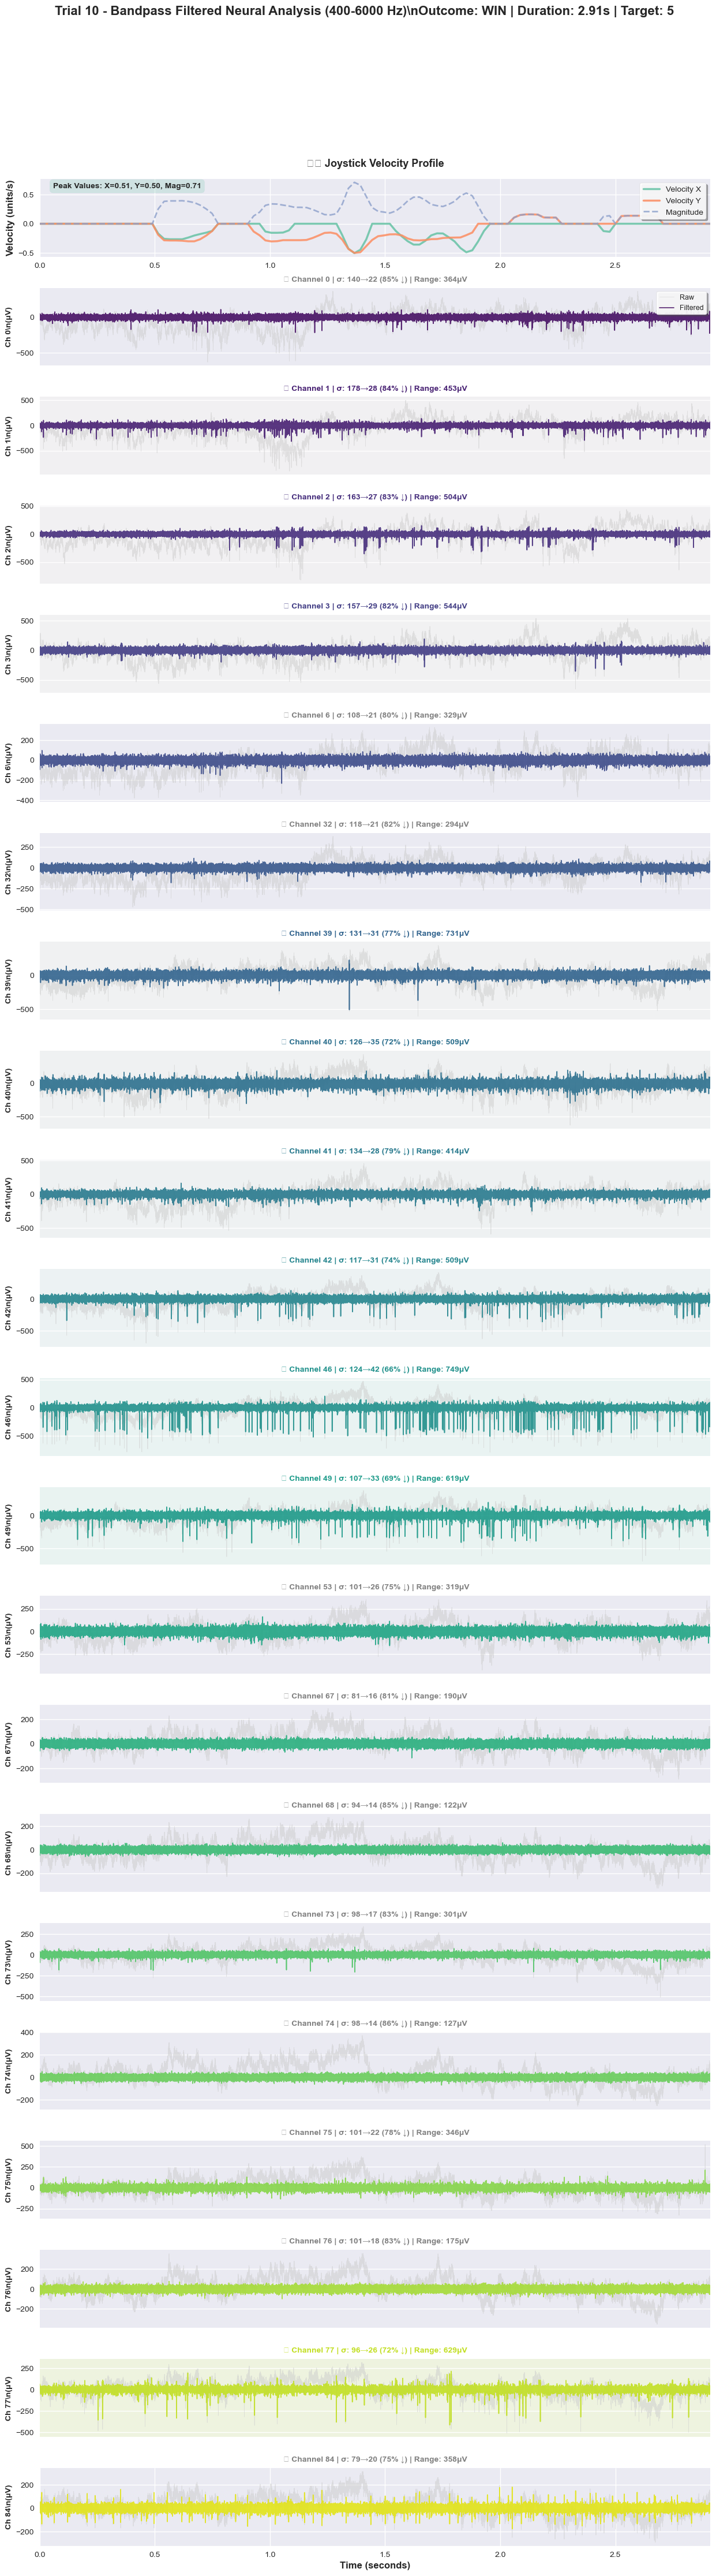

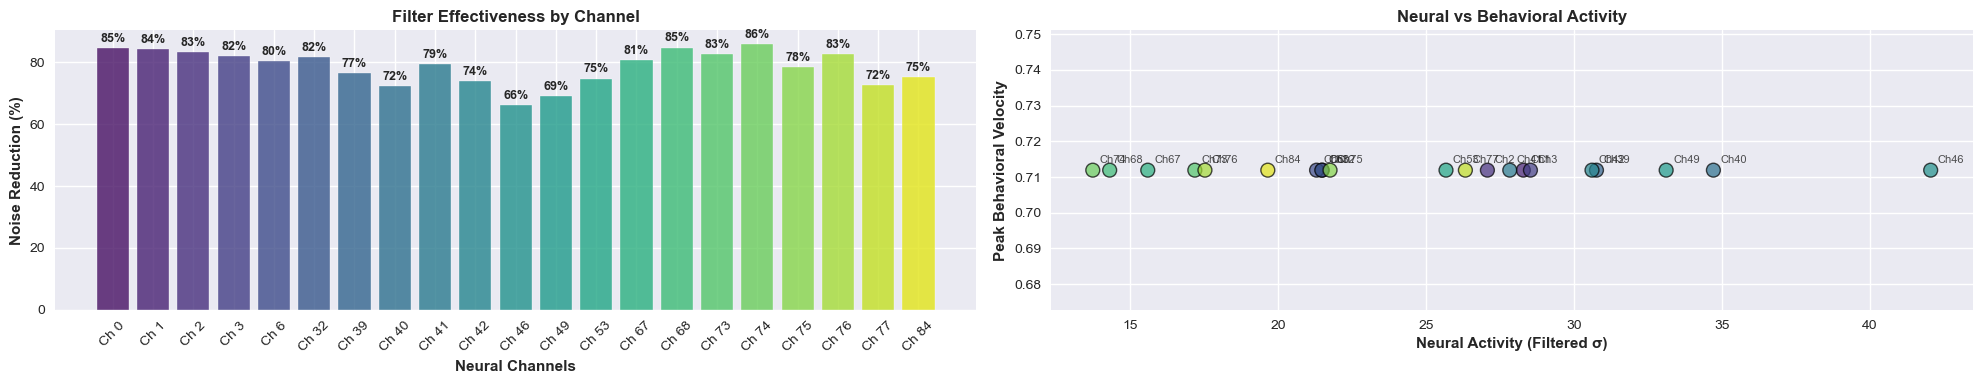

\n================================================================================
📊 TRIAL 10 COMPREHENSIVE ANALYSIS SUMMARY
\n🕹️  BEHAVIORAL PERFORMANCE:
   • Velocity X: μ=-0.083 ± σ=0.134 | Peak: 0.505
   • Velocity Y: μ=-0.091 ± σ=0.157 | Peak: 0.501
   • Magnitude:  μ= 0.165 ± σ=0.175 | Peak: 0.712
   • Movement time: 1.71s (58.8% of trial)
   • Stillness time: 1.20s (41.2% of trial)
\n🧠 NEURAL ACTIVITY ANALYSIS (Filtered 400-6000 Hz):
   Channel  Raw σ    Filt σ   Reduction  Activity   Status
   -------- -------- -------- ---------- ---------- ----------
   Ch  0      140.1     21.5     84.7%    📊 MOD    ⚠️
   Ch  1      177.8     28.3     84.1%    🔥 HIGH    ⚠️
   Ch  2      162.9     27.1     83.4%    🔥 HIGH    ⚠️
   Ch  3      157.5     28.5     81.9%    🔥 HIGH    ⚠️
   Ch  6      107.9     21.3     80.3%    📊 MOD    ⚠️
   Ch 32      117.9     21.5     81.8%    📊 MOD    ⚠️
   Ch 39      131.3     30.8     76.6%    🔥 HIGH    ✅
   Ch 40      125.7     34.7     72.4%    🔥 HIGH    

In [ ]:
# Create synchronized visualization with bandpass filtering
if 'trial_data' in locals() and trial_data is not None:
    print(f"🎨 Creating synchronized visualization for trial {TRIAL_NUMBER}...")
    
    # Extract data
    neural_data = trial_data['neural_data']
    velocity_x = trial_data['velocity_x']
    velocity_y = trial_data['velocity_y']
    behavioral_timestamps = trial_data['behavioral_timestamps']
    
    if neural_data is None:
        print("❌ No neural data found!")
    elif velocity_x is None or velocity_y is None:
        print("❌ No behavioral data found!")
    else:
        print(f"📊 Data shapes:")
        print(f"   Neural: {neural_data.shape} (channels × time)")
        print(f"   Velocity: {velocity_x.shape} samples")
        
        # Apply bandpass filter to neural data
        print(f"🔧 Applying bandpass filter ({FILTER_LOW}-{FILTER_HIGH} Hz)...")
        filtered_neural = bandpass_filter(neural_data, FILTER_LOW, FILTER_HIGH, SAMPLING_RATE, FILTER_ORDER)
        
        # Create time axes
        neural_samples = neural_data.shape[1]
        neural_time = np.linspace(0, trial_data['duration'], neural_samples)
        
        # Convert behavioral timestamps to relative time
        if behavioral_timestamps is not None and len(behavioral_timestamps) > 0:
            behavioral_time = behavioral_timestamps - behavioral_timestamps[0]
        else:
            behavioral_time = np.linspace(0, trial_data['duration'], len(velocity_x))
        
        # Select channels for visualization
        if USE_SPIKE_CHANNELS_ONLY:
            # Use only manually identified spike channels
            available_spike_channels = [ch for ch in SPIKE_CHANNELS if ch < neural_data.shape[0]]
            selected_channels = np.array(available_spike_channels)
            n_channels_to_plot = len(selected_channels)
            print(f"Using {n_channels_to_plot} spike channels: {selected_channels}")
        else:
            # Use random channel selection
            np.random.seed(RANDOM_SEED)
            n_channels_to_plot = min(N_CHANNELS, neural_data.shape[0])
            selected_channels = np.random.choice(neural_data.shape[0], n_channels_to_plot, replace=False)
            selected_channels = np.sort(selected_channels)
            print(f"Using {n_channels_to_plot} random channels: {selected_channels}")
        
        print(f"🧠 Selected channels: {selected_channels}")
        print(f"⏱️  Time alignment: Neural {neural_time[-1]:.2f}s, Behavioral {behavioral_time[-1]:.2f}s")
        
        # Calculate dynamic figure size based on number of channels being plotted
        figure_size = calculate_figure_size(n_channels_to_plot)
        print(f"📏 Creating figure with size: {figure_size} for {n_channels_to_plot} channels")
        
        # Create the figure with seaborn styling
        fig = plt.figure(figsize=figure_size, facecolor='white')
        gs = fig.add_gridspec(n_channels_to_plot + 1, 1, hspace=0.4, top=0.90, bottom=0.08)
        
        # Enhanced title with better formatting
        outcome_color = BEHAVIORAL_COLORS[0] if trial_data["outcome"] == "win" else BEHAVIORAL_COLORS[1]
        fig.suptitle(f'Trial {TRIAL_NUMBER} - Bandpass Filtered Neural Analysis ({FILTER_LOW}-{FILTER_HIGH} Hz)\\n'
                     f'Outcome: {trial_data["outcome"].upper()} | Duration: {trial_data["duration"]:.2f}s | '
                     f'Target: {trial_data.get("target_index", "N/A")}', 
                     fontsize=16, fontweight='bold', y=0.96)
        
        # Plot behavioral velocity (top subplot) with enhanced styling
        ax_behavior = fig.add_subplot(gs[0])
        
        # Plot velocity components with seaborn colors
        ax_behavior.plot(behavioral_time, velocity_x, color=BEHAVIORAL_COLORS[0], 
                        linewidth=2.5, label='Velocity X', alpha=0.85)
        ax_behavior.plot(behavioral_time, velocity_y, color=BEHAVIORAL_COLORS[1], 
                        linewidth=2.5, label='Velocity Y', alpha=0.85)
        
        # Calculate and plot velocity magnitude
        velocity_magnitude = np.sqrt(velocity_x**2 + velocity_y**2)
        ax_behavior.plot(behavioral_time, velocity_magnitude, color=BEHAVIORAL_COLORS[2], 
                        linewidth=2.0, linestyle='--', label='Magnitude', alpha=0.8)
        
        # Style the behavioral plot
        ax_behavior.set_ylabel('Velocity (units/s)', fontweight='bold', fontsize=12)
        ax_behavior.set_title('🕹️ Joystick Velocity Profile', fontweight='bold', pad=15, fontsize=13)
        
        # Enhanced legend
        legend = ax_behavior.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=10)
        legend.get_frame().set_facecolor('white')
        legend.get_frame().set_alpha(0.9)
        
        ax_behavior.set_xlim(0, max(neural_time[-1], behavioral_time[-1]))
        sns.despine(ax=ax_behavior, top=True, right=True)
        
        # Enhanced statistics box
        vel_stats = f'Peak Values: X={np.max(np.abs(velocity_x)):.2f}, Y={np.max(np.abs(velocity_y)):.2f}, Mag={np.max(velocity_magnitude):.2f}'
        ax_behavior.text(0.02, 0.95, vel_stats, transform=ax_behavior.transAxes, 
                        bbox=dict(boxstyle="round,pad=0.4", facecolor=BEHAVIORAL_COLORS[0], alpha=0.2, edgecolor=BEHAVIORAL_COLORS[0]),
                        fontsize=10, verticalalignment='top', fontweight='bold')
        
        # Calculate activity levels for color coding
        filt_stds = [np.std(filtered_neural[ch, :]) for ch in selected_channels]
        activity_threshold = np.median(filt_stds)
        
        # Plot filtered neural recordings with enhanced styling
        for i, channel_idx in enumerate(selected_channels):
            ax = fig.add_subplot(gs[i + 1])
            
            # Get original and filtered signals
            original_signal = neural_data[channel_idx, :]
            filtered_signal = filtered_neural[channel_idx, :]
            
            # Use different colors for different channels
            neural_color = NEURAL_COLORS[i % len(NEURAL_COLORS)]
            
            # Plot both signals with enhanced styling
            ax.plot(neural_time, original_signal, color=FILTER_COLORS["raw"], 
                   linewidth=0.6, alpha=0.5, label='Raw' if i == 0 else "")
            ax.plot(neural_time, filtered_signal, color=neural_color, 
                   linewidth=1.2, alpha=0.9, label='Filtered' if i == 0 else "")
            
            # Calculate statistics
            orig_std = np.std(original_signal)
            filt_std = np.std(filtered_signal)
            filt_range = np.ptp(filtered_signal)
            reduction_pct = (1 - filt_std/orig_std) * 100
            
            # Enhanced subplot styling
            ax.set_ylabel(f'Ch {channel_idx}\\n(μV)', fontweight='bold', fontsize=10)
            
            # Color-coded title based on activity level
            title_color = neural_color if filt_std > activity_threshold else 'gray'
            activity_indicator = "🔥" if filt_std > activity_threshold else "📊"
            
            ax.set_title(f'{activity_indicator} Channel {channel_idx} | '
                        f'σ: {orig_std:.0f}→{filt_std:.0f} ({reduction_pct:.0f}% ↓) | Range: {filt_range:.0f}μV', 
                        fontsize=10, pad=8, color=title_color, fontweight='bold')
            
            ax.set_xlim(0, max(neural_time[-1], behavioral_time[-1]))
            sns.despine(ax=ax, top=True, right=True)
            
            # Add subtle background coloring for high-activity channels
            if filt_std > activity_threshold:
                ax.set_facecolor(sns.light_palette(neural_color, as_cmap=False)[0])
            
            # Enhanced legend only on first neural plot
            if i == 0:
                legend = ax.legend(loc='upper right', frameon=True, fancybox=True, 
                                 shadow=True, fontsize=9)
                legend.get_frame().set_facecolor('white')
                legend.get_frame().set_alpha(0.9)
            
            # Only show x-axis label on bottom subplot
            if i == len(selected_channels) - 1:
                ax.set_xlabel('Time (seconds)', fontweight='bold', fontsize=12)
            else:
                ax.set_xticks([])
        
        # Show the enhanced plot
        plt.show()
        
        # Create a summary statistics plot with dynamic width based on number of channels
        stats_width = max(12, min(n_channels_to_plot * 0.8 + 8, 20))  # Scale with channels, 12-20" range
        stats_height = 4
        fig_stats, (ax_bar, ax_scatter) = plt.subplots(1, 2, figsize=(stats_width, stats_height))
        
        # Bar plot of filter effectiveness per channel
        channel_names = [f'Ch {ch}' for ch in selected_channels]
        reduction_percentages = []
        for ch in selected_channels:
            orig = np.std(neural_data[ch, :])
            filt = np.std(filtered_neural[ch, :])
            reduction_percentages.append((1 - filt/orig) * 100)
        
        bars = ax_bar.bar(channel_names, reduction_percentages, 
                         color=NEURAL_COLORS[:len(selected_channels)], alpha=0.8)
        ax_bar.set_title('Filter Effectiveness by Channel', fontweight='bold', fontsize=12)
        ax_bar.set_ylabel('Noise Reduction (%)', fontweight='bold')
        ax_bar.set_xlabel('Neural Channels', fontweight='bold')
        ax_bar.tick_params(axis='x', rotation=45)
        sns.despine(ax=ax_bar, top=True, right=True)
        
        # Add value labels on bars
        for bar, val in zip(bars, reduction_percentages):
            ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                       f'{val:.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
        
        # Scatter plot of behavioral activity vs neural activity
        neural_activity = [np.std(filtered_neural[ch, :]) for ch in selected_channels]
        behavioral_activity_levels = np.ones(len(selected_channels)) * np.max(velocity_magnitude)
        
        scatter = ax_scatter.scatter(neural_activity, behavioral_activity_levels, 
                                   c=NEURAL_COLORS[:len(selected_channels)], 
                                   s=100, alpha=0.7, edgecolors='black', linewidth=1)
        
        ax_scatter.set_xlabel('Neural Activity (Filtered σ)', fontweight='bold')
        ax_scatter.set_ylabel('Peak Behavioral Velocity', fontweight='bold')
        ax_scatter.set_title('Neural vs Behavioral Activity', fontweight='bold', fontsize=12)
        sns.despine(ax=ax_scatter, top=True, right=True)
        
        # Add channel labels to scatter points
        for i, ch in enumerate(selected_channels):
            ax_scatter.annotate(f'Ch{ch}', (neural_activity[i], behavioral_activity_levels[i]),
                              xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)
        
        plt.tight_layout()
        plt.show()
        
        # Enhanced summary statistics with formatting
        print("\\n" + "="*80)
        print(f"📊 TRIAL {TRIAL_NUMBER} COMPREHENSIVE ANALYSIS SUMMARY")
        print("="*80)
        
        print(f"\\n🕹️  BEHAVIORAL PERFORMANCE:")
        print(f"   • Velocity X: μ={np.mean(velocity_x):6.3f} ± σ={np.std(velocity_x):5.3f} | Peak: {np.max(np.abs(velocity_x)):5.3f}")
        print(f"   • Velocity Y: μ={np.mean(velocity_y):6.3f} ± σ={np.std(velocity_y):5.3f} | Peak: {np.max(np.abs(velocity_y)):5.3f}")
        print(f"   • Magnitude:  μ={np.mean(velocity_magnitude):6.3f} ± σ={np.std(velocity_magnitude):5.3f} | Peak: {np.max(velocity_magnitude):5.3f}")
        
        # Calculate movement metrics
        movement_duration = np.sum(velocity_magnitude > 0.01) / len(velocity_magnitude) * trial_data['duration']
        stillness_pct = (1 - movement_duration / trial_data['duration']) * 100
        
        print(f"   • Movement time: {movement_duration:.2f}s ({100-stillness_pct:.1f}% of trial)")
        print(f"   • Stillness time: {trial_data['duration']-movement_duration:.2f}s ({stillness_pct:.1f}% of trial)")
        
        print(f"\\n🧠 NEURAL ACTIVITY ANALYSIS (Filtered {FILTER_LOW}-{FILTER_HIGH} Hz):")
        print(f"   {'Channel':<8} {'Raw σ':<8} {'Filt σ':<8} {'Reduction':<10} {'Activity':<10} {'Status'}")
        print(f"   {'-'*8} {'-'*8} {'-'*8} {'-'*10} {'-'*10} {'-'*10}")
        
        total_reduction = 0
        high_activity_count = 0
        
        for ch in selected_channels:
            orig_signal = neural_data[ch, :]
            filt_signal = filtered_neural[ch, :]
            orig_std = np.std(orig_signal)
            filt_std = np.std(filt_signal)
            reduction_pct = (1 - filt_std/orig_std) * 100
            total_reduction += reduction_pct
            
            # Activity classification
            if filt_std > activity_threshold:
                activity_status = "🔥 HIGH"
                high_activity_count += 1
            else:
                activity_status = "📊 MOD"
            
            status_emoji = "✅" if 20 <= reduction_pct <= 80 else "⚠️"
            
            print(f"   Ch {ch:2d}     {orig_std:6.1f}   {filt_std:6.1f}   {reduction_pct:6.1f}%    {activity_status}    {status_emoji}")
        
        avg_reduction = total_reduction / len(selected_channels)
        
        print(f"\\n📈 SUMMARY METRICS:")
        print(f"   • Average noise reduction: {avg_reduction:.1f}%")
        print(f"   • High-activity channels: {high_activity_count}/{len(selected_channels)} ({high_activity_count/len(selected_channels)*100:.1f}%)")
        print(f"   • Filter frequency range: {FILTER_LOW}-{FILTER_HIGH} Hz ({FILTER_HIGH-FILTER_LOW} Hz bandwidth)")
        
        print(f"\\n⚡ QUALITY ASSESSMENT:")
        time_diff = abs(neural_time[-1] - behavioral_time[-1])
        time_status = "✅ EXCELLENT" if time_diff < 0.5 else "✅ GOOD" if time_diff < 1.0 else "⚠️ NEEDS CHECK"
        
        filter_effectiveness = avg_reduction
        filter_status = "✅ EXCELLENT" if filter_effectiveness > 50 else "✅ GOOD" if filter_effectiveness > 30 else "⚠️ MODERATE"
        
        behavioral_activity = np.max(velocity_magnitude)
        activity_status = "✅ VERY ACTIVE" if behavioral_activity > 0.5 else "✅ ACTIVE" if behavioral_activity > 0.1 else "⚠️ LOW ACTIVITY"
        
        print(f"   • Time alignment:     {time_status:<15} (Δt = {time_diff:.3f}s)")
        print(f"   • Filter performance: {filter_status:<15} ({avg_reduction:.1f}% noise reduction)")
        print(f"   • Behavioral activity: {activity_status:<15} (peak = {behavioral_activity:.3f})")
        print(f"   • Data completeness:  {'✅ COMPLETE':<15} (Neural: {neural_data.shape[1]} samples, Behavioral: {len(velocity_x)} samples)")
        
        print("\\n" + "="*80)

else:
    print("❌ No trial data available for visualization!")